# Fraud Detection – Feature Reduction

This notebook performs the feature reduction stage of the pipeline.

It loads the preprocessed data from `data/processed/`, selects the most informative features using filter methods (correlation & mutual information), and optionally applies PCA for further dimensionality reduction.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_selection import mutual_info_classif
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import joblib
import os

# For reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Plot settings
plt.rcParams['figure.figsize'] = (12, 6)
%matplotlib inline

## 1. Load Preprocessed Data

We use the files saved by the preprocessing notebook. These have already been cleaned, encoded, and scaled.

In [2]:
# Load feature matrices and target vectors
X_train = pd.read_csv("../data/processed/X_train.csv")
X_test  = pd.read_csv("../data/processed/X_test.csv")
y_train = pd.read_csv("../data/processed/y_train.csv").values.ravel()
y_test  = pd.read_csv("../data/processed/y_test.csv").values.ravel()

print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)

Training set shape: (472432, 422)
Test set shape: (118108, 422)


## 2. Initial Feature Exploration

Before selection, we quickly check for any constant or low‑variance columns (should already be handled, but it’s a safe check).

In [3]:
# Remove zero-variance features if any remain
variance_mask = X_train.var() > 0
constant_cols = X_train.columns[~variance_mask].tolist()
if constant_cols:
    print("Dropping constant columns:", constant_cols)
    X_train = X_train.loc[:, variance_mask]
    X_test  = X_test.loc[:, variance_mask]
else:
    print("No constant columns found.")

print("Shape after removing constants:", X_train.shape)

No constant columns found.
Shape after removing constants: (472432, 422)


## 3. Feature Selection using Mutual Information

Mutual information measures the dependency between each feature and the target, capturing non‑linear relationships as well.
Because the dataset is large, we compute MI on a **random sample** of the training data (e.g., 2%) to speed up the process.

In [4]:
# Sample for quick MI computation (use 20% of data)
sample_frac = 0.02
X_sample = X_train.sample(frac=sample_frac, random_state=RANDOM_STATE)
y_sample = y_train[X_sample.index]  # align target using index

# Calculate mutual information scores
mi_scores = mutual_info_classif(X_sample, y_sample, random_state=RANDOM_STATE)
mi_series = pd.Series(mi_scores, index=X_train.columns).sort_values(ascending=False)

# Display top 15
print("Top 15 features by Mutual Information:")
print(mi_series.head(15))

Top 15 features by Mutual Information:
C4      0.025092
C8      0.024380
V258    0.024278
V242    0.023830
V246    0.023180
V259    0.022997
V199    0.022773
V257    0.022417
V200    0.022270
V187    0.022229
V201    0.022079
C7      0.021337
V189    0.021236
V275    0.020881
V274    0.020303
dtype: float64


### Visualise MI Scores

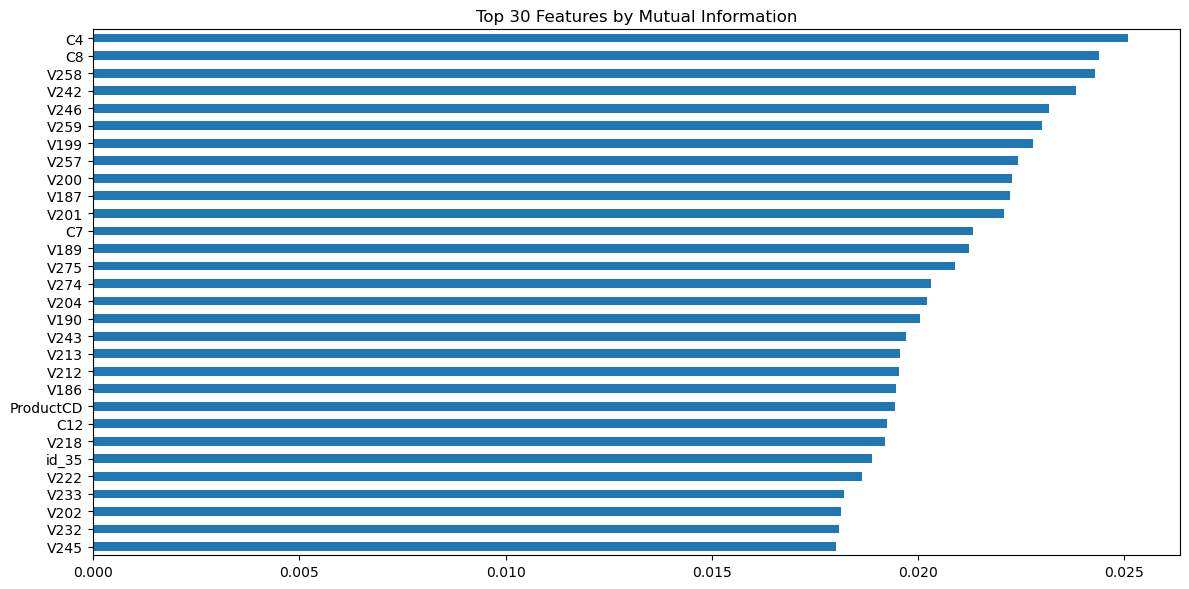

In [5]:
plt.figure()
mi_series.head(30).plot(kind='barh', title='Top 30 Features by Mutual Information')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig("../results/figures/mi_scores.png")
plt.show()

## 4. Select Top *k* Features

We keep the top 50 features (can be adjusted) based on mutual information.

In [6]:
k = 50
selected_features = mi_series.head(k).index.tolist()
print(f"Selected top {k} features.")

# Reduce datasets to selected features
X_train_selected = X_train[selected_features]
X_test_selected  = X_test[selected_features]

print("Reduced training set shape:", X_train_selected.shape)
print("Reduced test set shape:", X_test_selected.shape)

Selected top 50 features.
Reduced training set shape: (472432, 50)
Reduced test set shape: (118108, 50)


### Save list of selected features

In [7]:
# Save list of selected features for later use
os.makedirs("../data/processed", exist_ok=True)
pd.Series(selected_features).to_csv("../data/processed/selected_features.csv", index=False, header=False)
print("Selected features saved.")

Selected features saved.


## 5. Dimensionality Reduction with PCA

If we want to compress the feature space even further, we can apply PCA on the selected features. We will keep enough components to explain 95% of the variance.

In [8]:
# Scale the selected features (though they should already be scaled, it's safe to re-scale)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_selected)
X_test_scaled  = scaler.transform(X_test_selected)

# Fit PCA on training data
pca = PCA(n_components=0.95, random_state=RANDOM_STATE)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca  = pca.transform(X_test_scaled)

print("Original number of features:", X_train_selected.shape[1])
print("Number of PCA components (95% variance):", pca.n_components_)
print("Cumulative explained variance:", np.cumsum(pca.explained_variance_ratio_)[-1])

Original number of features: 50
Number of PCA components (95% variance): 16
Cumulative explained variance: 0.9539144728783762


### Visualise PCA variance

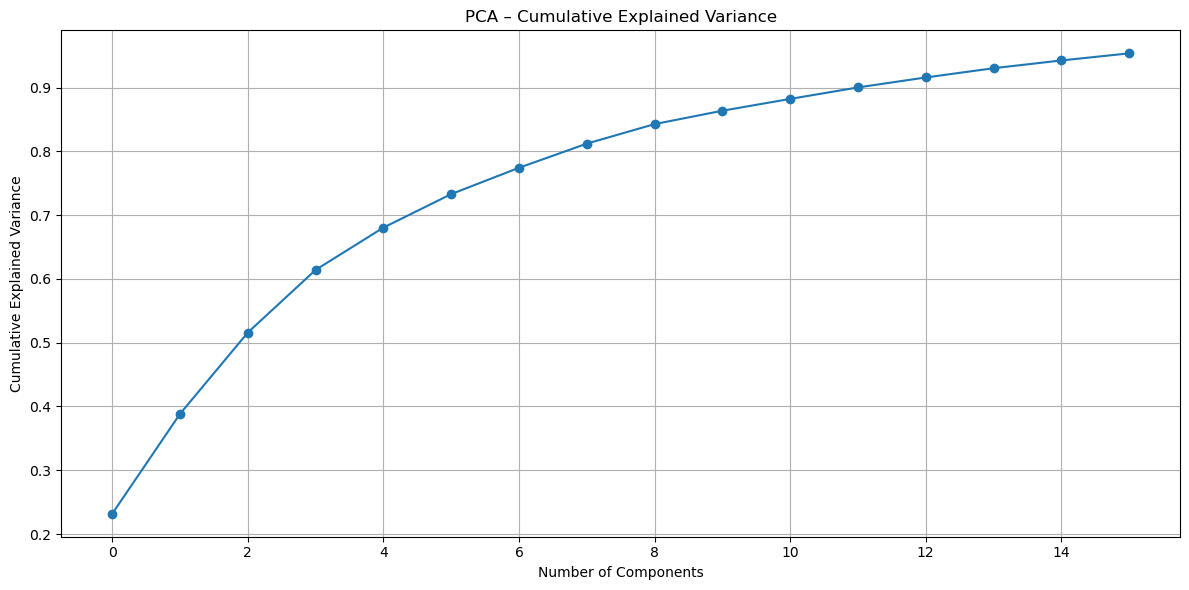

In [9]:
plt.figure()
plt.plot(np.cumsum(pca.explained_variance_ratio_), marker='o')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA – Cumulative Explained Variance')
plt.grid(True)
plt.tight_layout()
plt.savefig("../results/figures/pca_variance.png")
plt.show()

## 6. Save Final Reduced Data

We'll save both the selected‑features version and the PCA version so Member 4 can choose which to use.
We also save the PCA object and the scaler used for PCA.

In [10]:
# Save the 'selected features' version
X_train_selected.to_csv("../data/processed/X_train_selected.csv", index=False)
X_test_selected.to_csv("../data/processed/X_test_selected.csv", index=False)

# Save the PCA version (convert to DataFrame for consistency)
pd.DataFrame(X_train_pca, columns=[f"PC{i+1}" for i in range(X_train_pca.shape[1])]).to_csv("../data/processed/X_train_pca.csv", index=False)
pd.DataFrame(X_test_pca, columns=[f"PC{i+1}" for i in range(X_test_pca.shape[1])]).to_csv("../data/processed/X_test_pca.csv", index=False)

# Save transformation objects
joblib.dump(pca, "../data/processed/pca.pkl")
joblib.dump(scaler, "../data/processed/pca_scaler.pkl")

print("All reduced datasets and objects saved!")

All reduced datasets and objects saved!


## Summary

- Loaded preprocessed training and test sets.
- Computed mutual information scores to rank features.
- Selected the top 50 features (adjustable).
- Applied PCA to retain 95% variance, further reducing dimensions.
- Saved the reduced datasets (`_selected.csv`, `_pca.csv`) and necessary transformers.

**Next step:** Member 4 will use these files for model training.

*Note:* If the dataset is extremely large and the MI computation on a sample is still too heavy, consider using a smaller sample or using a parallelised joblib backend.